In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dataclasses import dataclass
import random
import matplotlib.pyplot as plt
import numpy as np
from flying_discs.frispy.base import FrispyCalculator
from flying_discs.frispy.constants import FrispyUltrastarConstants
from flying_discs.frispy.coordinates import FrispyPosition
from flying_discs.frispy.scipy_backend.disc import Disc
from flying_discs.frispy.jax_backend.disc import Disc as JAXDisc

In [3]:
@dataclass
class Experiment:
    vx0: float = 0.0
    vy0: float = 0.0
    vz0: float = 0.0
    phi: float = 0.0
    theta: float = 0.0
    gamma: float = 0.0
    dphi: float = 0.0
    dtheta: float = 0.0
    dgamma: float = 0.0

In [4]:
def get_random_experiment():
    z = random.uniform(0, 2)
    return (
        FrispyPosition(x=0, y=0, z=z),
        Experiment(
            random.uniform(0, 30),
            random.uniform(0, 30),
            random.uniform(0, 30),
            random.uniform(0, np.pi),
            random.uniform(0, np.pi),
            random.uniform(0, np.pi),
            random.uniform(0, np.pi),
            random.uniform(0, np.pi),
            random.uniform(0, np.pi),
        ))

In [5]:
n = 1000
experiments = [get_random_experiment() for _ in range(n)]

In [6]:
experiment = experiments[0]
initial_position = FrispyPosition(x=0, y=0, z=1)
disc = FrispyCalculator(FrispyUltrastarConstants(), True, False)
pos, experiment = get_random_experiment()
trajectory = disc.calculate_trajectory(
    initial_position=pos,
    vx0=experiment.vx0,
    vy0=experiment.vy0,
    vz0=experiment.vz0,
    phi=experiment.phi,
    theta=experiment.theta,
    gamma=experiment.gamma,
    dphi=experiment.dphi,
    dtheta=experiment.dtheta,
    dgamma=experiment.dgamma,
    deltaT=0.033,
)

E0328 22:33:19.266939  358757 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0328 22:33:19.279032  358655 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


In [7]:
import time
st = time.time()
for pos, experiment in experiments:
    disc.calculate_trajectory(
        initial_position=pos,
        vx0=experiment.vx0,
        vy0=experiment.vy0,
        vz0=experiment.vz0,
        phi=experiment.phi,
        theta=experiment.theta,
        gamma=experiment.gamma,
        dphi=experiment.dphi,
        dtheta=experiment.dtheta,
        dgamma=experiment.dgamma,
        deltaT=0.033,
    )
et = time.time()
jax_time = et - st
print(jax_time / n)

0.006093427896499633


In [8]:
import time
st = time.time()
disc = FrispyCalculator(FrispyUltrastarConstants(), False)
for pos, experiment in experiments:
    disc.calculate_trajectory(
        initial_position=initial_position,
        vx0=experiment.vx0,
        vy0=experiment.vy0,
        vz0=experiment.vz0,
        phi=experiment.phi,
        theta=experiment.theta,
        gamma=experiment.gamma,
        dphi=experiment.dphi,
        dtheta=experiment.dtheta,
        dgamma=experiment.dgamma,
        deltaT=0.033,
    )
et = time.time()
scipy_time = et - st
print(scipy_time / n)

0.019087273359298707


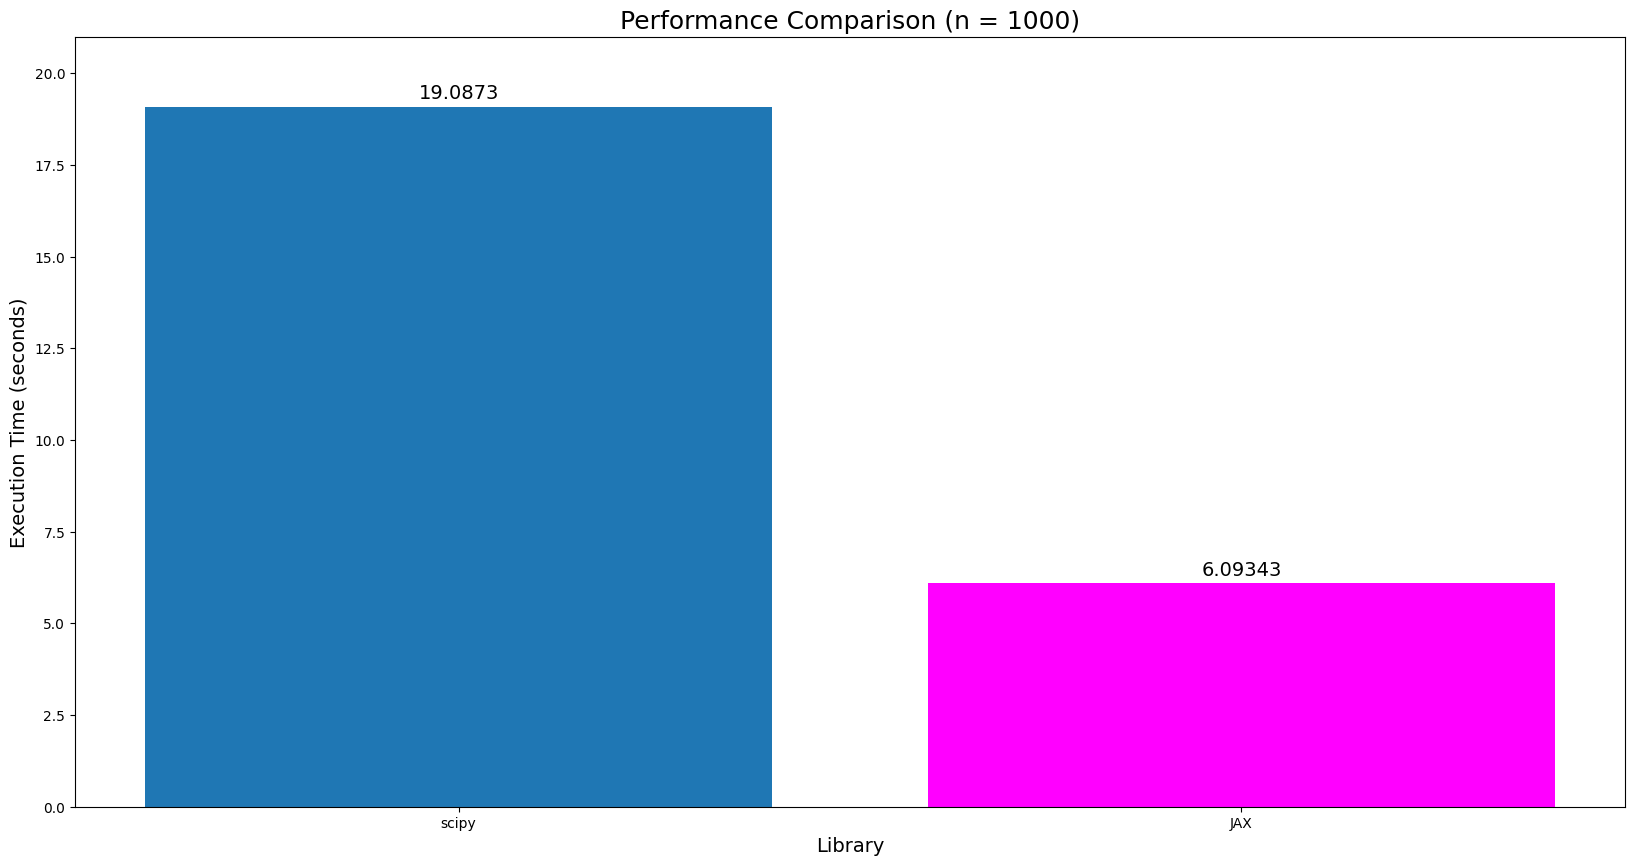

In [12]:
import matplotlib.pyplot as plt

# Data
labels = ["scipy", "JAX"]
times = [scipy_time, jax_time]
colors = ['tab:blue', 'magenta']

# Set up the plot
fig, ax = plt.subplots(figsize=(20,10))
bars = ax.bar(labels, times, color=colors)

# 1. Add number labels to each bar
# padding=3 adds a small gap between the bar and the text
ax.bar_label(bars, padding=3, fontsize=14)

# 2. Set the y axis range (min, max)
# Setting the max slightly higher than the data (e.g., 2.0) leaves room for labels
ax.set_ylim(0, max([scipy_time, jax_time]) * 1.1)

# Add titles and axis labels
ax.set_xlabel("Library", fontsize=14)
ax.set_ylabel("Execution Time (seconds)", fontsize=14)
ax.set_title(f"Performance Comparison (n = {n})", fontsize=18)
plt.show()

In [13]:
scipy_time / jax_time

3.1324360743258124